# Kernel circle lemma concentration

This notebook is for concentration-only analysis of `kernel_circle_lemma_concentration` runs.
It assumes compact per-run artifacts (no dynamics, no full matrices).

Main goals:
- aggregate lemma errors across many random seeds,
- plot concentration vs sample size `n`,
- compare empirical exceedance to theoretical concentration envelopes,
- inspect per-mode action relative errors.

In [2]:
import os
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
# Reset to default Matplotlib theme (ignore custom project theme for this notebook)
mpl.rcdefaults()
plt.style.use("default")

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
print("Project root added to sys.path:", ROOT)

from utils.artifacts_io import latest_run_dir, load_manifest, npz

Project root added to sys.path: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments


In [3]:
BASE = "../results"
EXP_NAME = "kernel_circle_lemma_concentration"

plot_dir = Path("plots") / EXP_NAME
plot_dir.mkdir(parents=True, exist_ok=True)
print("Plots will be saved to:", plot_dir)

Plots will be saved to: plots/kernel_circle_lemma_concentration


In [4]:
run_dir = latest_run_dir(BASE, EXP_NAME)
if run_dir is None:
    raise FileNotFoundError(f"No run found for experiment '{EXP_NAME}' in {BASE}")

manifest = load_manifest(run_dir)
print("Loaded run dir:", run_dir)
print("Run count:", len(manifest["runs"]))
print("n_trains:", manifest["meta"].get("n_trains"))
print("seeds:", manifest["meta"].get("seeds"))
print("K_max:", manifest["meta"].get("K_max"))
print("kernel:", manifest["meta"].get("kernel"))
print("run_dynamics:", manifest["meta"].get("run_dynamics"))
print("save_full_matrices:", manifest["meta"].get("save_full_matrices"))

Loaded run dir: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/kernel_circle_lemma_concentration/20260421-171456-7b493dda
Run count: 900
n_trains: [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
K_max: 10
kernel: bias
run_dynamics: False
save_full_matrices: False


In [5]:
runs = {run_key: npz(run_dir, rel_path) for run_key, rel_path in manifest["runs"].items()}
print("Loaded per-run files:", len(runs))

Loaded per-run files: 900


In [6]:
def parse_run_key(run_key: str):
    # expected format: size_<n>_seed_<s>
    parts = run_key.split("_")
    n = int(parts[1])
    seed = int(parts[3])
    return n, seed


def decode_mode_names(arr):
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return out


def unpack_run(run_key: str, arrs: dict) -> dict:
    n, seed = parse_run_key(run_key)

    out = {
        "run_key": run_key,
        "n": n,
        "seed": seed,
        "gram_err_max": float(np.asarray(arrs["gram_err_max"])),
        "gram_err_fro": float(np.asarray(arrs["gram_err_fro"])),
        "comp_err_max": float(np.asarray(arrs["comp_err_max"])),
        "comp_err_fro": float(np.asarray(arrs["comp_err_fro"])),
        "action_err_max": float(np.asarray(arrs["action_err_max"])),
        "action_err_fro": float(np.asarray(arrs["action_err_fro"])),
        "per_mode_action_relerr": np.asarray(arrs["per_mode_action_relerr"], dtype=float),
        "mode_names": decode_mode_names(arrs["mode_names"]),
        "mode_freqs": np.asarray(arrs["mode_freqs"], dtype=int),
        "mode_types": decode_mode_names(arrs["mode_types"]),
    }

    if "Lambda_n_diag" in arrs:
        out["Lambda_n_diag"] = np.asarray(arrs["Lambda_n_diag"], dtype=float)
    if "g0" in arrs:
        out["g0"] = float(np.ravel(arrs["g0"])[0])

    return out


A = {run_key: unpack_run(run_key, arrs) for run_key, arrs in runs.items()}
print("Unpacked runs:", len(A))

Unpacked runs: 900


In [7]:
by_n = defaultdict(list)
for _, run in A.items():
    by_n[run["n"]].append(run)

for n in sorted(by_n):
    seeds = sorted(r["seed"] for r in by_n[n])
    print(f"n={n:5d}  runs={len(by_n[n]):4d}  seed_min={seeds[0]}  seed_max={seeds[-1]}")

n=   64  runs= 100  seed_min=0  seed_max=99
n=  128  runs= 100  seed_min=0  seed_max=99
n=  256  runs= 100  seed_min=0  seed_max=99
n=  512  runs= 100  seed_min=0  seed_max=99
n= 1024  runs= 100  seed_min=0  seed_max=99
n= 2048  runs= 100  seed_min=0  seed_max=99
n= 4096  runs= 100  seed_min=0  seed_max=99
n= 8192  runs= 100  seed_min=0  seed_max=99
n=16384  runs= 100  seed_min=0  seed_max=99


In [8]:
METRICS = [
    ("gram_err_max", r"$\|G-I\|_{\max}$"),
    ("gram_err_fro", r"$\|G-I\|_F$"),
    ("comp_err_max", r"$\|H-\Lambda^{(n)}\|_{\max}$"),
    ("comp_err_fro", r"$\|H-\Lambda^{(n)}\|_F$"),
    ("action_err_max", r"$\|A\Phi-\Phi\Lambda^{(n)}\|_{\max}$"),
    ("action_err_fro", r"$\|A\Phi-\Phi\Lambda^{(n)}\|_F$"),
]


def aggregate_metric_by_n(by_n_dict, metric_name: str):
    ns = sorted(by_n_dict.keys())

    means = []
    stds = []
    mins = []
    maxs = []
    all_vals = []

    for n in ns:
        vals = np.array([run[metric_name] for run in by_n_dict[n]], dtype=float)
        means.append(vals.mean())
        stds.append(vals.std())
        mins.append(vals.min())
        maxs.append(vals.max())
        all_vals.append(vals)

    return {
        "ns": np.array(ns, dtype=int),
        "mean": np.array(means, dtype=float),
        "std": np.array(stds, dtype=float),
        "min": np.array(mins, dtype=float),
        "max": np.array(maxs, dtype=float),
        "all": all_vals,
    }


agg = {name: aggregate_metric_by_n(by_n, name) for name, _ in METRICS}

for metric_name, label in METRICS:
    d = agg[metric_name]
    print(f"\n=== {metric_name} ({label}) ===")
    for n, mean, std in zip(d["ns"], d["mean"], d["std"]):
        print(f"n={n:5d}   mean={mean:.4e}   std={std:.4e}")


=== gram_err_max ($\|G-I\|_{\max}$) ===
n=   64   mean=3.4634e-01   std=5.5719e-02
n=  128   mean=2.4211e-01   std=4.2590e-02
n=  256   mean=1.7039e-01   std=3.2945e-02
n=  512   mean=1.2104e-01   std=1.7959e-02
n= 1024   mean=8.4194e-02   std=1.3519e-02
n= 2048   mean=5.9024e-02   std=8.8504e-03
n= 4096   mean=4.2320e-02   std=6.9247e-03
n= 8192   mean=3.0974e-02   std=4.7897e-03
n=16384   mean=2.1263e-02   std=3.3678e-03

=== gram_err_fro ($\|G-I\|_F$) ===
n=   64   mean=2.5286e+00   std=3.1755e-01
n=  128   mean=1.7798e+00   std=2.1278e-01
n=  256   mean=1.2752e+00   std=1.7070e-01
n=  512   mean=8.8608e-01   std=9.7863e-02
n= 1024   mean=6.2581e-01   std=8.0329e-02
n= 2048   mean=4.3996e-01   std=5.6647e-02
n= 4096   mean=3.1410e-01   std=4.3685e-02
n= 8192   mean=2.2549e-01   std=2.6571e-02
n=16384   mean=1.5842e-01   std=2.0218e-02

=== comp_err_max ($\|H-\Lambda^{(n)}\|_{\max}$) ===
n=   64   mean=1.8218e-01   std=4.5256e-02
n=  128   mean=1.2356e-01   std=3.4680e-02
n=  256   

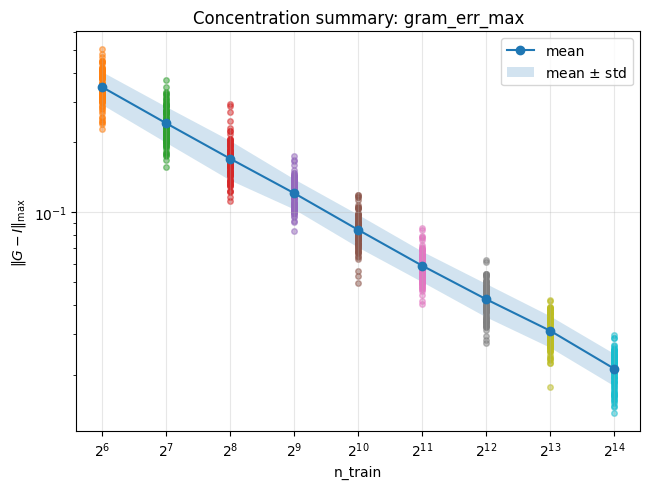

Saved plots/kernel_circle_lemma_concentration/concentration_gram_err_max.png


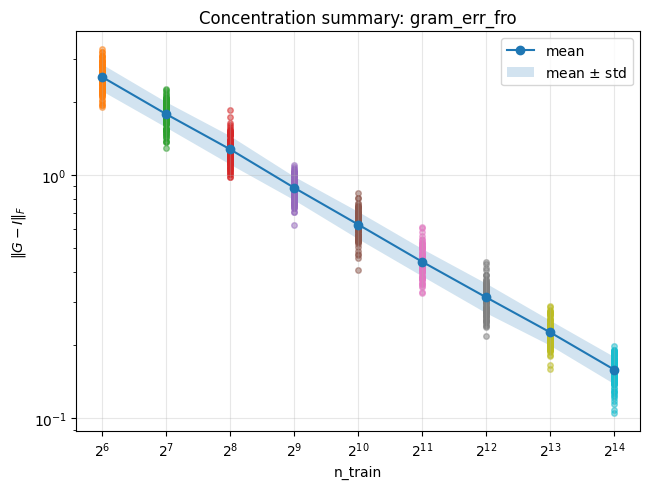

Saved plots/kernel_circle_lemma_concentration/concentration_gram_err_fro.png


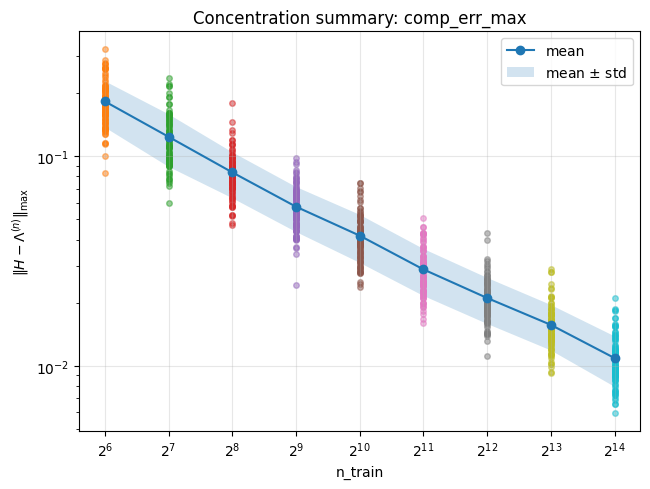

Saved plots/kernel_circle_lemma_concentration/concentration_comp_err_max.png


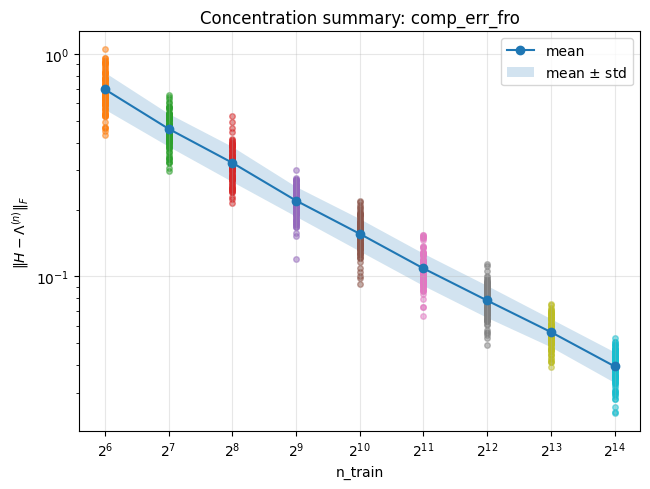

Saved plots/kernel_circle_lemma_concentration/concentration_comp_err_fro.png


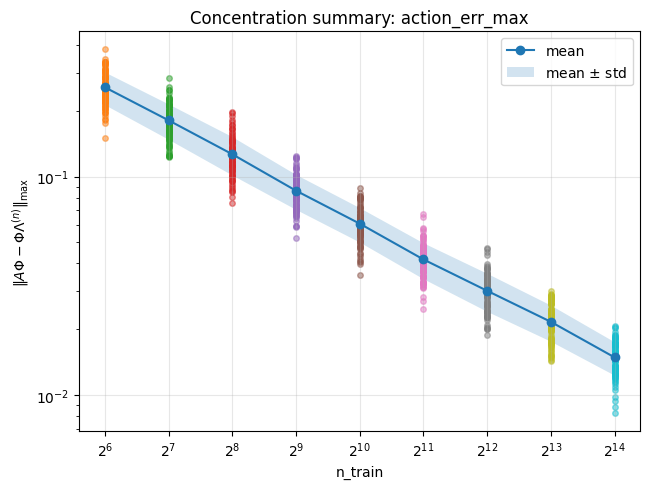

Saved plots/kernel_circle_lemma_concentration/concentration_action_err_max.png


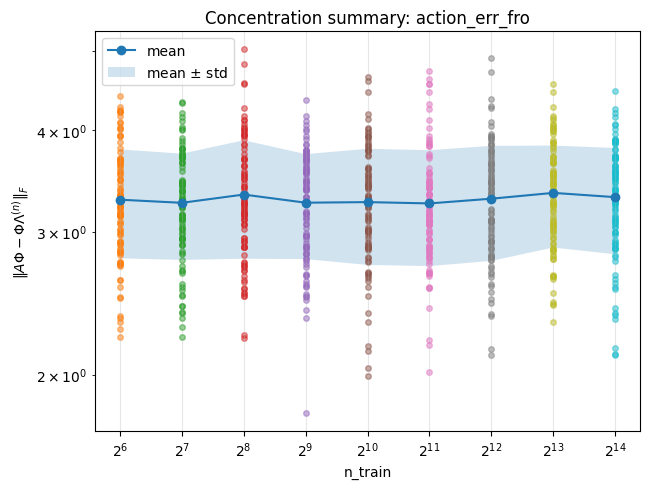

Saved plots/kernel_circle_lemma_concentration/concentration_action_err_fro.png


In [9]:
for metric_name, label in METRICS:
    d = agg[metric_name]
    ns = d["ns"]
    mean = d["mean"]
    std = d["std"]

    plt.figure(figsize=(6.6, 5.0))
    plt.plot(ns, mean, marker="o", label="mean")
    plt.fill_between(ns, np.maximum(mean - std, 1e-16), mean + std, alpha=0.2, label=r"mean $\pm$ std")

    for i, n in enumerate(ns):
        plt.scatter(np.full_like(d["all"][i], n, dtype=float), d["all"][i], s=16, alpha=0.5)

    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel("n_train")
    plt.ylabel(label)
    plt.title(f"Concentration summary: {metric_name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    out_path = plot_dir / f"concentration_{metric_name}.png"
    plt.savefig(out_path, dpi=160)
    plt.show()
    print("Saved", out_path)

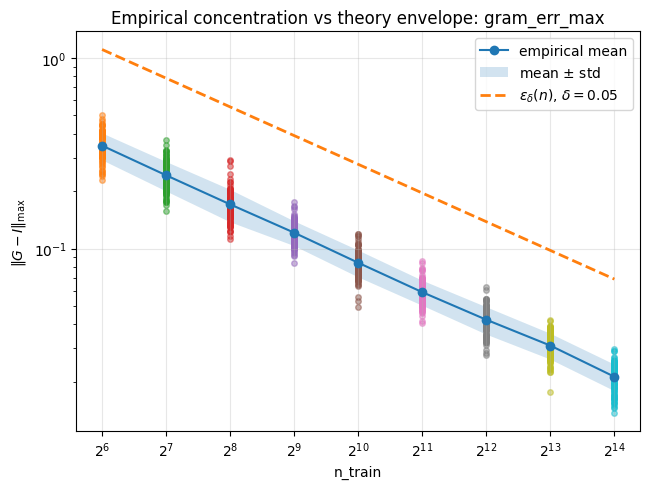

Saved plots/kernel_circle_lemma_concentration/theory_envelope_gram_err_max.png


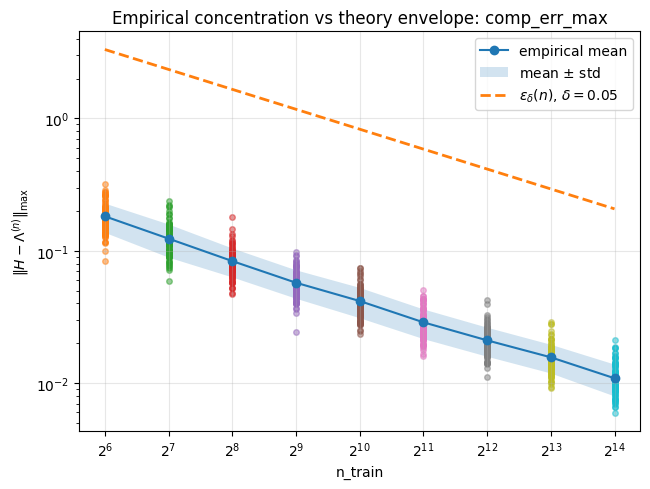

Saved plots/kernel_circle_lemma_concentration/theory_envelope_comp_err_max.png


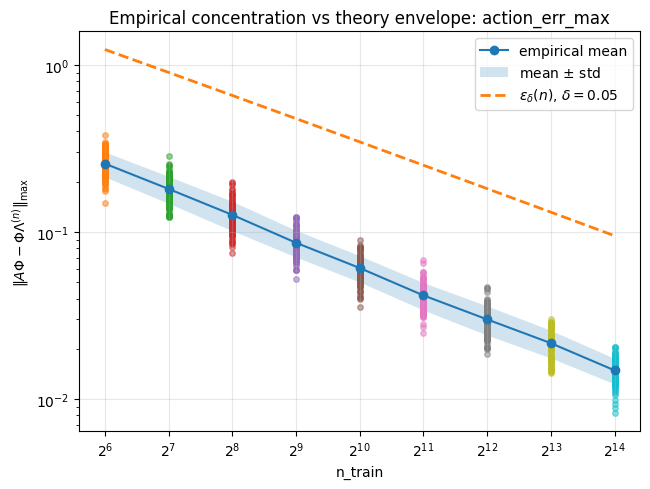

Saved plots/kernel_circle_lemma_concentration/theory_envelope_action_err_max.png


In [10]:
# Theoretical envelopes for max-norm metrics at confidence level delta
delta = 0.05

# Fourier block size d
d = len(by_n[sorted(by_n.keys())[0]][0]["mode_names"])

# Bias kernel sup norm bound used in prior notebook derivations
kappa = 1.5


def eps_gram(ns, d=d, delta=delta):
    return np.sqrt(8.0 * np.log(2.0 * d**2 / delta) / ns)


def eps_comp(ns, d=d, kappa=kappa, delta=delta):
    return np.sqrt(32.0 * kappa**2 * np.log(2.0 * d**2 / delta) / ns)


def eps_action(ns, d=d, kappa=kappa, delta=delta):
    return np.sqrt(4.0 * kappa**2 * np.log(2.0 * ns * d / delta) / ns)


THEORY_EPS = {
    "gram_err_max": eps_gram,
    "comp_err_max": eps_comp,
    "action_err_max": eps_action,
}

LABELS = {name: label for name, label in METRICS}

for metric_name in ["gram_err_max", "comp_err_max", "action_err_max"]:
    d_agg = agg[metric_name]
    ns = d_agg["ns"].astype(float)
    mean = d_agg["mean"]
    std = d_agg["std"]
    eps_vals = THEORY_EPS[metric_name](ns)

    plt.figure(figsize=(6.6, 5.0))
    plt.plot(ns, mean, marker="o", label="empirical mean")
    plt.fill_between(ns, np.maximum(mean - std, 1e-16), mean + std, alpha=0.2, label=r"mean $\pm$ std")

    for i, n in enumerate(ns):
        plt.scatter(np.full_like(d_agg["all"][i], n, dtype=float), d_agg["all"][i], s=16, alpha=0.5)

    plt.plot(ns, eps_vals, "--", linewidth=2.0, label=fr"$\epsilon_\delta(n)$, $\delta={delta}$")

    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel("n_train")
    plt.ylabel(LABELS[metric_name])
    plt.title(f"Empirical concentration vs theory envelope: {metric_name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    out_path = plot_dir / f"theory_envelope_{metric_name}.png"
    plt.savefig(out_path, dpi=160)
    plt.show()
    print("Saved", out_path)

In [11]:
# Exceedance check at epsilon_delta(n): should be <= delta in the ideal concentration statement
for metric_name in ["gram_err_max", "comp_err_max", "action_err_max"]:
    d_agg = agg[metric_name]
    ns = d_agg["ns"].astype(float)
    eps_vals = THEORY_EPS[metric_name](ns)

    print(f"\n=== {metric_name} exceedance at epsilon_delta(n), delta={delta} ===")
    print("   n      epsilon_delta      exceed / total      empirical_prob")
    for i, n in enumerate(ns):
        vals = np.asarray(d_agg["all"][i], dtype=float)
        eps = eps_vals[i]
        exc = int(np.sum(vals >= eps))
        tot = int(vals.size)
        print(f"{int(n):5d}   {eps: .4e}       {exc:3d} / {tot:3d}         {exc/tot: .4f}")


=== gram_err_max exceedance at epsilon_delta(n), delta=0.05 ===
   n      epsilon_delta      exceed / total      empirical_prob
   64    1.1055e+00         0 / 100          0.0000
  128    7.8174e-01         0 / 100          0.0000
  256    5.5277e-01         0 / 100          0.0000
  512    3.9087e-01         0 / 100          0.0000
 1024    2.7639e-01         0 / 100          0.0000
 2048    1.9544e-01         0 / 100          0.0000
 4096    1.3819e-01         0 / 100          0.0000
 8192    9.7718e-02         0 / 100          0.0000
16384    6.9097e-02         0 / 100          0.0000

=== comp_err_max exceedance at epsilon_delta(n), delta=0.05 ===
   n      epsilon_delta      exceed / total      empirical_prob
   64    3.3166e+00         0 / 100          0.0000
  128    2.3452e+00         0 / 100          0.0000
  256    1.6583e+00         0 / 100          0.0000
  512    1.1726e+00         0 / 100          0.0000
 1024    8.2916e-01         0 / 100          0.0000
 2048    5.863

In [12]:
# Direct Gram bound check for fixed epsilon values:
#   P(||G-I||_max >= epsilon) <= 2 d^2 exp(-n epsilon^2 / 8)
eps_grid = [0.10, 0.15, 0.20, 0.25]

ns = sorted(by_n.keys())

for eps in eps_grid:
    print(f"\n=== Gram fixed-epsilon check: epsilon={eps:.3f} ===")
    print("   n      empirical_prob      rhs_bound")
    for n in ns:
        vals = np.array([run["gram_err_max"] for run in by_n[n]], dtype=float)
        emp_prob = float(np.mean(vals >= eps))
        rhs = float(2.0 * d**2 * np.exp(-n * eps**2 / 8.0))
        rhs = min(rhs, 1.0)
        print(f"{n:5d}   {emp_prob: .4f}           {rhs: .4f}")


=== Gram fixed-epsilon check: epsilon=0.100 ===
   n      empirical_prob      rhs_bound
   64    1.0000            1.0000
  128    1.0000            1.0000
  256    1.0000            1.0000
  512    0.9100            1.0000
 1024    0.1100            1.0000
 2048    0.0000            1.0000
 4096    0.0000            1.0000
 8192    0.0000            0.0315
16384    0.0000            0.0000

=== Gram fixed-epsilon check: epsilon=0.150 ===
   n      empirical_prob      rhs_bound
   64    1.0000            1.0000
  128    1.0000            1.0000
  256    0.7100            1.0000
  512    0.0500            1.0000
 1024    0.0000            1.0000
 2048    0.0000            1.0000
 4096    0.0000            0.0088
 8192    0.0000            0.0000
16384    0.0000            0.0000

=== Gram fixed-epsilon check: epsilon=0.200 ===
   n      empirical_prob      rhs_bound
   64    1.0000            1.0000
  128    0.8600            1.0000
  256    0.1400            1.0000
  512    0.0000    

In [9]:
# Confidence level
delta = 0.05

# Fourier block size
d = len(by_n[sorted(by_n.keys())[0]][0]["mode_names"])

# Bias-kernel sup norm
kappa = 1.5

LABELS = {name: label for name, label in METRICS}


# ------------------------------------------------------------
# Old envelopes from the original proofs
# ------------------------------------------------------------

def eps_gram_old(ns, d=d, delta=delta):
    return np.sqrt(8.0 * np.log(2.0 * d**2 / delta) / ns)

def eps_comp_old(ns, d=d, kappa=kappa, delta=delta):
    return np.sqrt(32.0 * kappa**2 * np.log(2.0 * d**2 / delta) / ns)

def eps_action_old(ns, d=d, kappa=kappa, delta=delta):
    return np.sqrt(4.0 * kappa**2 * np.log(2.0 * ns * d / delta) / ns)


# ------------------------------------------------------------
# Refined envelopes
# ------------------------------------------------------------
# Gram: Bernstein + symmetry
#   P <= d(d+1) exp( - n eps^2 / (4 + (4/3) eps) )
#
# Action: Bernstein
#   P <= 2 n d exp( - n eps^2 / (2 kappa^2 + 4 kappa eps) )
#
# Comp: only symmetry-improved McDiarmid unless a real Bernstein
#       V-statistic bound is derived
#   P <= d(d+1) exp( - n eps^2 / (32 kappa^2) )
# ------------------------------------------------------------

def _solve_scalar_envelope(target_log_prefactor, n, denom_fn, tol=1e-10, max_iter=200):
    """
    Solve for eps > 0 in
        target_log_prefactor - n eps^2 / denom_fn(eps) = log(delta)
    equivalently
        prefactor * exp( - n eps^2 / denom_fn(eps) ) = delta

    Parameters
    ----------
    target_log_prefactor : float
        log(prefactor / delta)
    n : float
    denom_fn : callable
        denom_fn(eps) > 0
    """
    # We solve
    #     n eps^2 / denom_fn(eps) = target_log_prefactor
    # The left-hand side is increasing in eps for our cases.
    def f(eps):
        return n * eps**2 / denom_fn(eps) - target_log_prefactor

    lo = 0.0
    hi = 1.0
    while f(hi) < 0:
        hi *= 2.0
        if hi > 1e6:
            raise RuntimeError("Failed to bracket envelope root.")

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        if f(mid) >= 0:
            hi = mid
        else:
            lo = mid
        if hi - lo < tol:
            break
    return hi


def eps_gram_refined(ns, d=d, delta=delta):
    ns = np.asarray(ns, dtype=float)
    out = np.zeros_like(ns, dtype=float)

    # d(d+1) * exp( - n eps^2 / (4 + 4 eps / 3) ) <= delta
    target = np.log(d * (d + 1) / delta)

    for i, n in enumerate(ns):
        out[i] = _solve_scalar_envelope(
            target_log_prefactor=target,
            n=n,
            denom_fn=lambda eps: 4.0 + (4.0 / 3.0) * eps,
        )
    return out


def eps_comp_refined(ns, d=d, kappa=kappa, delta=delta):
    """
    Symmetry-improved McDiarmid envelope:
        d(d+1) exp( - n eps^2 / (32 kappa^2) ) <= delta
    """
    ns = np.asarray(ns, dtype=float)
    return np.sqrt(32.0 * kappa**2 * np.log(d * (d + 1) / delta) / ns)


def eps_action_refined(ns, d=d, kappa=kappa, delta=delta):
    ns = np.asarray(ns, dtype=float)
    out = np.zeros_like(ns, dtype=float)

    # 2 n d * exp( - n eps^2 / (2 kappa^2 + 4 kappa eps) ) <= delta
    for i, n in enumerate(ns):
        target = np.log(2.0 * n * d / delta)
        out[i] = _solve_scalar_envelope(
            target_log_prefactor=target,
            n=n,
            denom_fn=lambda eps: 2.0 * kappa**2 + 4.0 * kappa * eps,
        )
    return out


OLD_EPS = {
    "gram_err_max": eps_gram_old,
    "comp_err_max": eps_comp_old,
    "action_err_max": eps_action_old,
}

REFINED_EPS = {
    "gram_err_max": eps_gram_refined,
    "comp_err_max": eps_comp_refined,
    "action_err_max": eps_action_refined,
}

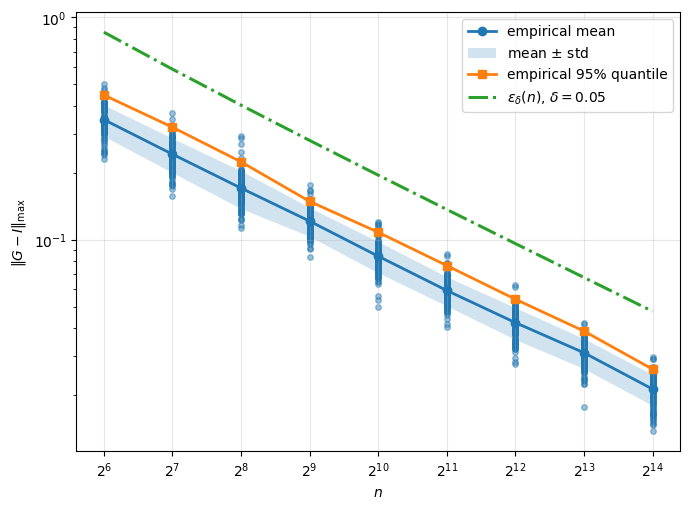

Saved plots/kernel_circle_lemma_concentration/theory_envelope_compare_gram_err_max.png


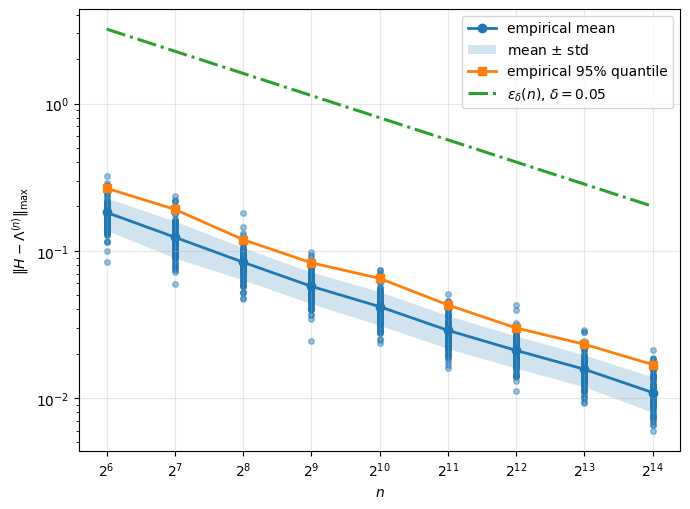

Saved plots/kernel_circle_lemma_concentration/theory_envelope_compare_comp_err_max.png


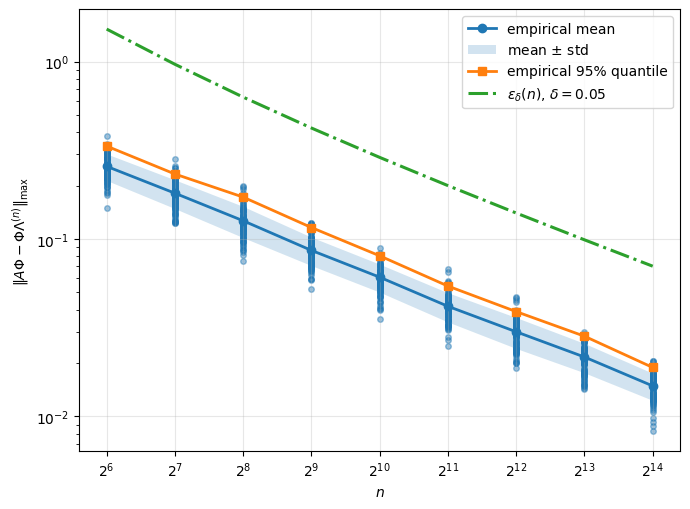

Saved plots/kernel_circle_lemma_concentration/theory_envelope_compare_action_err_max.png


In [11]:
for metric_name in ["gram_err_max", "comp_err_max", "action_err_max"]:
    d_agg = agg[metric_name]
    ns = d_agg["ns"].astype(float)
    mean = d_agg["mean"]
    std = d_agg["std"]
    all_vals = d_agg["all"]

    q_emp = np.array([np.quantile(vals, 1.0 - delta) for vals in all_vals], dtype=float)
    med_emp = np.array([np.median(vals) for vals in all_vals], dtype=float)

    eps_old = OLD_EPS[metric_name](ns)
    eps_ref = REFINED_EPS[metric_name](ns)

    plt.figure(figsize=(7.0, 5.2))

    # raw seed scatter
    for i, n in enumerate(ns):
        vals = np.asarray(all_vals[i], dtype=float)
        plt.scatter(np.full_like(vals, n, dtype=float), vals, s=16, alpha=0.45, color="C0")

    # empirical summaries
    plt.plot(ns, mean, marker="o", linewidth=2, label="empirical mean")
    plt.fill_between(
        ns,
        np.maximum(mean - std, 1e-16),
        mean + std,
        alpha=0.2,
        label=r"mean $\pm$ std",
    )
    plt.plot(ns, q_emp, marker="s", linewidth=2, label=fr"empirical {(1-delta):.0%} quantile")

    # theory envelopes
    # plt.plot(ns, eps_old, "--", linewidth=2.2, label="old envelope")
    plt.plot(ns, eps_ref, "-.", linewidth=2.2, label=fr"$\epsilon_\delta(n)$, $\delta={delta}$")

    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel(r"$n$")
    plt.ylabel(LABELS[metric_name])
    # plt.title(f"Empirical concentration vs old/refined envelopes: {metric_name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    out_path = plot_dir / f"theory_envelope_compare_{metric_name}.png"
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved", out_path)